<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Allison/ZIPCode_County.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import drive

drive.mount('/content/drive')

#Loading Data
path = "/content/drive/MyDrive/sparcs_model_v1.feather"
data = pd.read_feather(path)


#Looking at the Dataset Info
#print(data.shape)
#data.info()
#data.head()


#Looking at ZIP Codes
print("Unique ZIP codes:", data['zip_code'].nunique())
print(sorted(data['zip_code'].unique()))
#There are 50 unique zip codes


categorical_cols = ['zip_code', 'health_service_area', 'facility_id', 'hospital_county', 'age_group',
                    'gender', 'race', 'ethnicity', 'admission_type', 'apr_mortality_risk',
                    'apr_severity_code', 'apr_drg_code', 'apr_mdc_code', 'ccsr_dx_code']
drop_columns=['disposition', 'discharge_year', 'ccsr_px_cod', 'apr_med_surg_desc']



#Creating a function to clean and prepare data set
def clean_data(df):

#Remove Duplicates
  df = df.drop_duplicates()

#Excluding the rows that do not have LOS; Missing data
  df = df.dropna(subset = ['length_of_stay'])

#Convert data to numerical, Drop those who can't convert
  df['length_of_stay'] = pd.to_numeric(df['length_of_stay'], errors='coerce')
  df = df.dropna(subset = ['length_of_stay'])

#Remove out-of-state ZIP Codes ('OOS')
  if 'Zip Code' in df.columns:
      df = df[df['zip_code'] != 'OOS']

  df = df.drop(columns =[c for c in drop_columns if c in df.columns], errors = 'ignore')

  return df

#Clean Data
data = clean_data(data)
print("Shape of cleaned data:", data.shape)  # rows, columns


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unique ZIP codes: 50
['100', '101', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', 'OOS']
Shape of cleaned data: (4206911, 30)


## Calculating ZIPCode and County averages LOS

zip_code
146    7.051989
139    6.539477
116    6.486469
126    6.451442
143    6.374330
132    6.372637
107    6.329236
142    6.261521
108    6.237835
100    6.216309
103    6.205276
104    6.102551
129    6.094193
112    6.086238
127    6.005486
106    5.986053
144    5.975597
124    5.968153
114    5.915576
137    5.887713
145    5.793204
122    5.746540
125    5.715281
138    5.711321
135    5.673067
105    5.668513
113    5.656494
OOS    5.638108
123    5.587238
147    5.548309
140    5.524004
141    5.523083
130    5.481962
111    5.480887
109    5.461492
131    5.416654
110    5.405616
120    5.385137
115    5.339587
136    5.299930
134    5.280654
121    5.276326
101    5.240782
128    5.225579
117    5.221323
133    5.155637
119    5.066858
118    4.992699
149    4.980285
148    4.891868
Name: length_of_stay, dtype: float64
hospital_county
Niagara           7.677080
Columbia          7.502921
Monroe            6.847551
Westchester       6.497653
Clinton           6.354384
Bro

<Axes: >

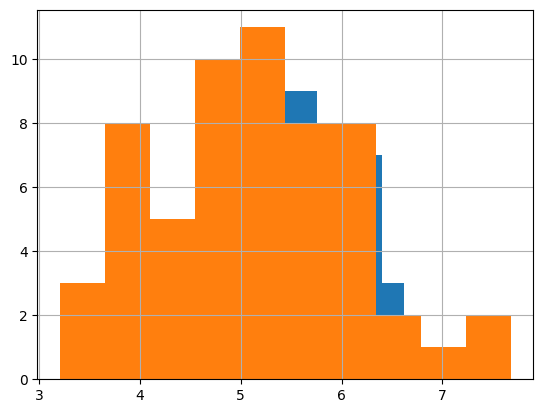

In [13]:
#Zip to strings
data['zip_code'] = data['zip_code'].astype(str)

#Calculate LOS Averages for ZIPCode & County
zip_averages = data.groupby('zip_code')['length_of_stay'].mean()
county_averages = data.groupby('hospital_county')['length_of_stay'].mean()

print(zip_averages.sort_values(ascending=False))
print(county_averages.sort_values(ascending=False))

zip_averages.hist()
county_averages.hist()

## **Average LOS by Zip/County Data Takeaway:**
County averages are far more meaningful than than the ZIP-Code averages. LOS ranges from ~7.7 days (Niagara) to ~3.2 days (Allegany). Difference of 4.5 days

ZIP Code is meaningful but noisy. Highest Zip ~7.05 days (146) and Lowest Zip ~4.89 days (148). Differences of 2.1 days (County is double this), many ZIP codes are close together. So it is hard for ZIP to be a strong predictive variable.


This means that at a County level, there could be differences in hospital systems, health resources, staffing, bed capacity...etc

The ZIP Codes are weaker because it often overlaps many Counties/cross County lines, and they are smaller geographical areas/units. We have 50 unique ZIP Codes but they do not match one-to-one with counties making them weaker.

COUNTY is better for comparing LOS!!


In [18]:
#Calculating Coefficient of Variation, measures relative variablity CV = Standard dev/Mean
#A lower CV = more stability

zip_cv = zip_averages.std() / zip_averages.mean()
county_cv = county_averages.std() / county_averages.mean()

print(f"ZIP-level CV: {zip_cv:.4f}")
print(f"County-level CV: {county_cv:.4f}")

ZIP-level CV: 0.0831
County-level CV: 0.1935


## **CV Data Takeaway:**
ZIP Code has low variability relative to LOS, explains why ZIP correlations with LOS are small.
County has moderate variability relative to LOS, so LOS varies more between Counties than ZIP Codes!! Counties capture a more real structural difference in hospital patterns

## **Calculating Correlations between ZIP Code/County and LOS**

In [14]:
# ZIP code correlations
corr_zip = pd.get_dummies(data[['zip_code']], drop_first=True)
corr_zip['length_of_stay'] = data['length_of_stay']
correlations_zip = corr_zip.corr()['length_of_stay']

# Hospital county correlations
corr_county = pd.get_dummies(data[['hospital_county']], drop_first=True)
corr_county['length_of_stay'] = data['length_of_stay']
correlations_county = corr_county.corr()['length_of_stay']


Top ZIP correlations:
 length_of_stay    1.000000
zip_code_146      0.023345
zip_code_112      0.011810
zip_code_104      0.010959
zip_code_142      0.008577
zip_code_103      0.007462
zip_code_116      0.007129
zip_code_132      0.006877
zip_code_107      0.006734
zip_code_126      0.005329
Name: length_of_stay, dtype: float64

Top County correlations:
 length_of_stay                 1.000000
hospital_county_Monroe         0.026975
hospital_county_Westchester    0.019380
hospital_county_Bronx          0.016792
hospital_county_Kings          0.015657
hospital_county_Niagara        0.012273
hospital_county_Columbia       0.007196
hospital_county_New York       0.005883
hospital_county_Onondaga       0.005847
hospital_county_Clinton        0.003807
Name: length_of_stay, dtype: float64


/tmp/ipython-input-4220532227.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([correlations_zip.values, correlations_county.values],


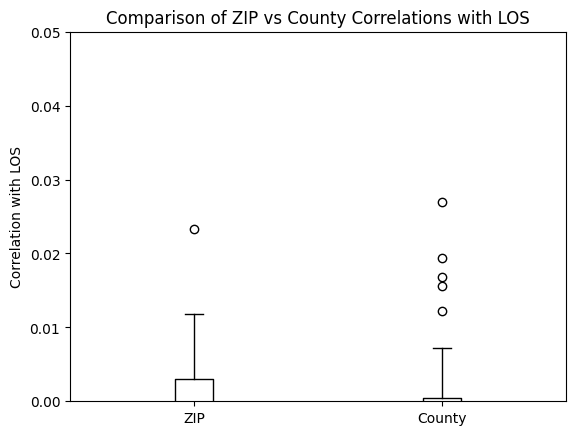

In [28]:
#Top 10 correlated ZIPCodes & County
top_zipcode_corr = correlations_zip.sort_values(ascending = False).head(10)
top_county_corr = correlations_county.sort_values(ascending = False).head(10)

print("Top ZIP correlations:\n", top_zipcode_corr)
print("\nTop County correlations:\n", top_county_corr)


plt.boxplot([correlations_zip.values, correlations_county.values],
            labels=['ZIP', 'County'])
plt.ylabel("Correlation with LOS")
plt.title("Comparison of ZIP vs County Correlations with LOS")
plt.ylim(0, 0.05) #match data range for easy visual

plt.show()

## **ZIP/County Correlation Data Takeaway:**
For ZIP CODE Correlation: highest correlation is 0.0233 (zip 146), which is extremely weak. Which confirms from earlier that Zip Code is granular and noisy, making it a weak predictor by itself.

For COUNTY Correlation: highest correlation is  0 026975 (Monroe), which is only slightly higher than the highest zip code.

So County is only slightly more meaningful that ZIP. But both ZIP and County individually correlate weakly with LOS (which we know that total_cost/risk_of_mortality was the highest correlator)

ZIP codes: high granularity, very weak individual predictive power, noisy.
Counties: slightly stronger, more stable slightly more meaningful.

## Given County is better for comparing LOS:
## Using an ANOVA to determine if there is significance in LOS across different counties

In [20]:
import scipy.stats as stats

#LOS per county:
groups = [group['length_of_stay'].values
          for _, group in data.groupby('hospital_county')]

#One-Way ANOVA:
f_stat, p_value = stats.f_oneway(*groups)

#Results:
print("ANOVA results (County -> LOS):")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.10f}")

ANOVA results (County -> LOS):
F-statistic: 299.9044
P-value: 0.0000000000


## **ANOVA Data Takeaway:**
F-statistic (299.904) is LARGE, means that there is a clear difference in LOS across counties. This validates previous data that Counties such as Niagara, Columbia, Monroe have significantly higher LOS than counties like Allegany or Chenango.
Even if correlations are low, County can be a meaningful predictor for LOS.

p-value (0.000) means that it is statistically significant

/tmp/ipython-input-3566028426.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([zip_averages.values, county_averages.values],


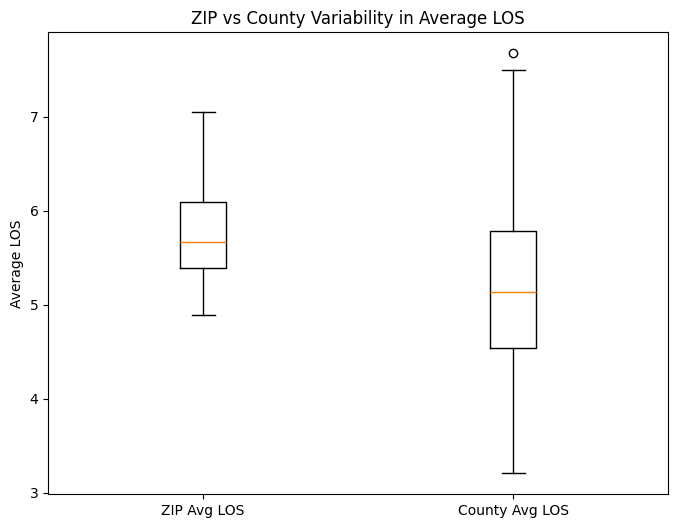

In [22]:
# Create variability plot of ZIPCode vs County
plt.figure(figsize=(8,6))
plt.boxplot([zip_averages.values, county_averages.values],
            labels=['ZIP Avg LOS', 'County Avg LOS'])

plt.ylabel("Average LOS")
plt.title("ZIP vs County Variability in Average LOS")
plt.show()

## **Variability Plot Takeaway:**
ZIP Code box is narrower: LOS is fairly stable/clustered within zips

County box is much taller, meaning greater spread in LOS between counties, confirming significance.